### ECSE415 - Introduction to Computer Vision
# Assignment 3
Anna Joy Aylward Burgess | 261124598 <br>
*March 18th, 2026*

## 0  Preparation



In [12]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

# path variable to folder with images
path = '/content/drive/My Drive/Colab Notebooks/ECSE 415 Assignments/As3/Q1/'

# import libraries
import time
import numpy as np
import cv2
import matplotlib # Added import for the base matplotlib module
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import gc
import os
import pandas as pd
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import time
from scipy import ndimage

print("External Libraries Used:")
print("NumPy version:", np.__version__)
print("OpenCV version:", cv2.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Pandas version:", pd.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
External Libraries Used:
NumPy version: 2.0.2
OpenCV version: 4.13.0
Matplotlib version: 3.10.0
Pandas version: 2.2.2


---

## 1   Image Classification with Convolution Neural Network (CNN) and Naïve Bayes [40 points]

**In this part, you will classify MNIST digits into 10 categories using a CNN. You may choose to run the code on GPU.**




###1.1  Download Dataset [2 points]

**Use PyTorch class torchvision.datasets.MNIST to (down)load the dataset. Use batch size of 32.**




In [2]:
# 1. Define transformations (Convert to Tensor and Normalize)
# Mean and Std for MNIST are generally 0.1307 and 0.3081
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 2. Download/Load Training and Test Sets
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# 3. Create DataLoaders with batch size of 32
batch_size = 32

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nSuccessfully loaded {len(train_dataset)} training images and {len(test_dataset)} test images.")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.11MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.89MB/s]


Successfully loaded 60000 training images and 10000 test images.


###1.2  Implement a CNN with the layers mentioned below [5 points]

- **Convolution layer with 32 kernels of size 3×3**  
- **ReLU activation**  
- **Convolution layer with 64 kernels of size 3×3**  
- **ReLU activation**  
- **MaxPool layer with kernel size 2×2**  
- **Convolution layer with 64 kernels of size 3×3**  
- **ReLU activation**  
- **Convolution layer with 64 kernels of size 3×3**  
- **ReLU activation**  
- **Flatten layer (reshapes feature map into a vector of length 4096)**  
- **Linear layer with output size 10**




In [3]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        # 1. Conv layer: 32 kernels, 3x3 (Output: 32, 26, 26)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)

        # 3. Conv layer: 64 kernels, 3x3 (Output: 64, 24, 24)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)

        # 5. Maxpool layer: 2x2 (Output: 64, 12, 12)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 6. Conv layer: 64 kernels, 3x3 (Output: 64, 10, 10)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3)

        # 8. Conv layer: 64 kernels, 3x3 (Output: 64, 8, 8)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3)

        # 11. Linear layer: Output size 10
        # Flattening 64 * 8 * 8 = 4096
        self.fc = nn.Linear(4096, 10)

    def forward(self, x):
        # Layer 1 & 2: Conv + ReLU
        x = F.relu(self.conv1(x))
        # Layer 3 & 4: Conv + ReLU
        x = F.relu(self.conv2(x))
        # Layer 5: Maxpool
        x = self.pool(x)
        # Layer 6 & 7: Conv + ReLU
        x = F.relu(self.conv3(x))
        # Layer 8 & 9: Conv + ReLU
        x = F.relu(self.conv4(x))

        # Layer 10: Flattening
        x = x.view(-1, 4096)

        # Layer 11: Linear
        x = self.fc(x)
        return x

# Instantiate the model and move it to the GPU (T4 on Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNIST_CNN().to(device)

print(model)

MNIST_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc): Linear(in_features=4096, out_features=10, bias=True)
)


###1.3  Create an instance of SGD optimizer with learning rate of 0.001. Use default settings for the remaining hyperparameters. Create an instance of categorical cross-entropy loss. [2 points]




In [4]:
# 1.3 Create an instance of categorical cross-entropy loss
criterion = nn.CrossEntropyLoss()

# Create an instance of SGD optimizer with learning rate of 0.001
# model.parameters() passes the weights of MNIST_CNN to the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

print("Loss function: Categorical Cross-Entropy")
print(f"Optimizer: SGD (Learning Rate: 0.001)")

Loss function: Categorical Cross-Entropy
Optimizer: SGD (Learning Rate: 0.001)


###1.4  Train the CNN for 10 epochs. Display loss and accuracy at each training step. [4 points]




In [5]:
epochs = 10
model.train() # Set model to training mode

print(f"Starting training on {device}...")

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy for this step
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        step_accuracy = 100 * (predicted == labels).sum().item() / labels.size(0)

        running_loss += loss.item()

        # Display loss and accuracy at each training step
        if (i + 1) % 500 == 0: # Printing every 500 steps to avoid crashing out
            print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], '
                  f'Loss: {loss.item():.4f}, Accuracy: {step_accuracy:.2f}%')

    # Print epoch summary
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f'--- Epoch {epoch+1} Summary: Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}% ---')

print("Training Complete!")

Starting training on cuda...
Epoch [1/10], Step [500/1875], Loss: 2.2468, Accuracy: 28.12%
Epoch [1/10], Step [1000/1875], Loss: 0.8460, Accuracy: 84.38%
Epoch [1/10], Step [1500/1875], Loss: 0.3190, Accuracy: 90.62%
--- Epoch 1 Summary: Loss: 1.2586, Accuracy: 65.53% ---
Epoch [2/10], Step [500/1875], Loss: 0.3967, Accuracy: 87.50%
Epoch [2/10], Step [1000/1875], Loss: 0.1579, Accuracy: 96.88%
Epoch [2/10], Step [1500/1875], Loss: 0.6315, Accuracy: 81.25%
--- Epoch 2 Summary: Loss: 0.3711, Accuracy: 88.79% ---
Epoch [3/10], Step [500/1875], Loss: 0.2257, Accuracy: 93.75%
Epoch [3/10], Step [1000/1875], Loss: 0.1605, Accuracy: 90.62%
Epoch [3/10], Step [1500/1875], Loss: 0.6956, Accuracy: 87.50%
--- Epoch 3 Summary: Loss: 0.2840, Accuracy: 91.67% ---
Epoch [4/10], Step [500/1875], Loss: 0.3770, Accuracy: 81.25%
Epoch [4/10], Step [1000/1875], Loss: 0.2020, Accuracy: 93.75%
Epoch [4/10], Step [1500/1875], Loss: 0.2993, Accuracy: 90.62%
--- Epoch 4 Summary: Loss: 0.2105, Accuracy: 93.80%

###1.5  Predict labels of the test images using the trained CNN. Report classification accuracy [2 points]




In [6]:
model.eval()  # Set the model to evaluation mode
correct = 0
total = 0

print("Evaluating the trained model on the test set...")

# Use no_grad to disable gradient calculation (saves memory and time)
with torch.no_grad():
    for images, labels in test_loader:
        # Move tensors to the same device as the model (cpu or cuda)
        images, labels = images.to(device), labels.to(device)

        # Forward pass to get outputs
        outputs = model(images)

        # The class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate final test accuracy
test_accuracy = 100 * correct / total

print("-" * 30)
print(f'Total Test Images: {total}')
print(f'Correct Predictions: {correct}')
print(f'Final Classification Accuracy: {test_accuracy:.2f}%')
print("-" * 30)

Evaluating the trained model on the test set...
------------------------------
Total Test Images: 10000
Correct Predictions: 9773
Final Classification Accuracy: 97.73%
------------------------------


###1.6 Show the effect of batch size on test classification accuracy. Use at least 4 different batch sizes (e.g., 4, 8, 12, 16). (You will need to re-train the model.) [3 points]




In [8]:
# Define at least 4 batch sizes as requested
batch_sizes = [8, 16, 32, 64]
comparison_results = []

print(f"Starting Batch Size Experiment on {device}...\n")

for bs in batch_sizes:
    print(f"--- Testing Batch Size: {bs} ---")

    # 1. Prepare DataLoaders with the specific batch size
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    # 2. Reset the Model, Loss, and Optimizer
    # re-initialize to get fresh weights
    model = MNIST_CNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

    # 3. Train for 10 epochs and measure time
    start_time = time.time()
    model.train()

    for epoch in range(10):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    end_time = time.time()
    elapsed_time = end_time - start_time

    # 4. Evaluate on Test Set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    comparison_results.append((bs, elapsed_time, accuracy))
    print(f"Result for BS {bs}: Time = {elapsed_time:.2f}s, Accuracy = {accuracy:.2f}%")

# 5. Display Final Results Table
print("\n" + "="*45)
print(f"{'Batch Size':<12} | {'Time (sec)':<12} | {'Accuracy (%)':<12}")
print("-" * 45)
for bs, t, acc in comparison_results:
    print(f"{bs:<12} | {t:<12.2f} | {acc:<12.2f}")
print("="*45)

Starting Batch Size Experiment on cuda...

--- Testing Batch Size: 8 ---
Result for BS 8: Time = 315.08s, Accuracy = 98.55%
--- Testing Batch Size: 16 ---
Result for BS 16: Time = 223.47s, Accuracy = 98.41%
--- Testing Batch Size: 32 ---
Result for BS 32: Time = 176.06s, Accuracy = 97.54%
--- Testing Batch Size: 64 ---
Result for BS 64: Time = 152.89s, Accuracy = 96.08%

Batch Size   | Time (sec)   | Accuracy (%)
---------------------------------------------
8            | 315.08       | 98.55       
16           | 223.47       | 98.41       
32           | 176.06       | 97.54       
64           | 152.89       | 96.08       


###1.7 Mention two activation functions other than ReLU. Re-train the model using these activations throughout the network and report the test accuracies. Discuss the results. [3 points]




In [9]:
# Helper function to build and train the model with a specific activation
def train_with_activation(activation_fn, name):
    print(f"\n--- Training with {name} Activation ---")

    class VariantCNN(nn.Module):
        def __init__(self):
            super(VariantCNN, self).__init__()
            # Using the same architecture as before
            self.conv1 = nn.Conv2d(1, 32, 3)
            self.conv2 = nn.Conv2d(32, 64, 3)
            self.pool = nn.MaxPool2d(2, 2)
            self.conv3 = nn.Conv2d(64, 64, 3)
            self.conv4 = nn.Conv2d(64, 64, 3)
            self.fc = nn.Linear(64 * 8 * 8, 10)

        def forward(self, x):
            # Apply the chosen activation function throughout
            x = activation_fn(self.conv1(x))
            x = activation_fn(self.conv2(x))
            x = self.pool(x)
            x = activation_fn(self.conv3(x))
            x = activation_fn(self.conv4(x))
            x = x.view(-1, 64 * 8 * 8)
            return self.fc(x)

    model = VariantCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

    # Train for 10 epochs
    model.train()
    for epoch in range(10):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            optimizer.step(criterion(model(images), labels).backward()) # Compact version

    # Evaluate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = torch.max(model(images).data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Final Accuracy with {name}: {accuracy:.2f}%")
    return accuracy

# Run the tests (Using F.sigmoid and torch.tanh)
sigmoid_acc = train_with_activation(torch.sigmoid, "Sigmoid")
tanh_acc = train_with_activation(torch.tanh, "Tanh")


--- Training with Sigmoid Activation ---
Final Accuracy with Sigmoid: 11.35%

--- Training with Tanh Activation ---
Final Accuracy with Tanh: 92.24%


*From theory, I expected that the performance based on accuracy would go from ReLU performing the best, then Tanh, then Sigmoid. This is because ReLU has a constant gradient which prevents the vanishing gradient problem and converges faster. Tanh should perform better than Sigmoid because it's optimization process is more stable because it's output range is -1 to 1, but it also suffers from the gradient issue. Sigmoid should have lowest accuracy for deep networks because the output is always positive and the gradient is vanishing.*

*This hypothesis is matched by the results where the ReLU accuracy is above 95% even for different batch sizes, Tanh is 92%, and Sigmoid is only 11.35%.*

###1.8 Use the CNN developed above to recognize the digits in the test images: Q1/test1.png, Q1/test2.png, and Q1/test3.png. [3 points]

*Include the details of important preprocessing steps. You may need to pre-process the input image before using the CNN to recognize the digit.*




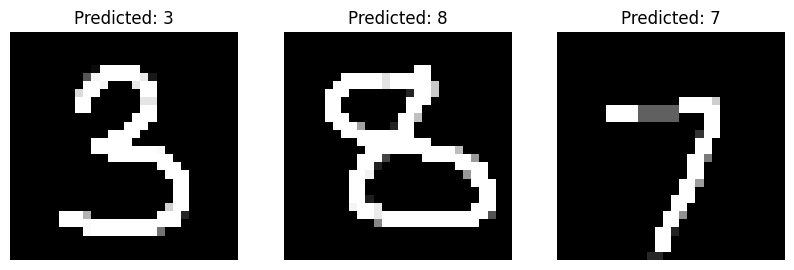

In [14]:
# Helper function to determine how much to shift image based on center of mass
# of the digit we want to detect
def get_best_shift(img):
    # Compute center of mass of the digit
    cy, cx = ndimage.center_of_mass(img)
    rows, cols = img.shape

    # Calculate how much to shift to move center to image center
    shiftx = np.round(cols/2.0 - cx).astype(int)
    shifty = np.round(rows/2.0 - cy).astype(int)
    return shiftx, shifty

# Helper function to shift the image
def shift(img, sx, sy):
    rows, cols = img.shape
    # Create affine transformation matrix for shifting
    M = np.float32([[1, 0, sx], [0, 1, sy]])

    # Apply shift to the image
    shifted = cv2.warpAffine(img, M, (cols, rows))
    return shifted

# Core function to predict the digit from the input image using the model
def predict_custom_image(image_path, model):
    # Read image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None, None

    # 1. Invert and Binarize (make digit white)
    img = cv2.bitwise_not(img)
    _, img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # 2. Crop to digit bounding box to remove empty space around the digit
    coords = cv2.findNonZero(img)
    x, y, w, h = cv2.boundingRect(coords)
    img = img[y:y+h, x:x+w]

    # 3. Resize to fit in a 20x20 box (preserving aspect ratio)
    if w > h:
        new_w = 20
        new_h = int(h * (20 / w))
    else:
        new_h = 20
        new_w = int(w * (20 / h))
    img = cv2.resize(img, (new_w, new_h))

    # 4. Pad to 28x28 to be MNIST standard input size
    pad_h = (28 - new_h) // 2
    pad_w = (28 - new_w) // 2
    img = cv2.copyMakeBorder(img, pad_h, 28-new_h-pad_h, pad_w, 28-new_w-pad_w,
                             cv2.BORDER_CONSTANT, value=0)

    # 5. Center the digit by mass within the frame
    sx, sy = get_best_shift(img)
    img = shift(img, sx, sy)

    # 6. Apply dialation to makes the strokes thicker to recognize easier
    kernel = np.ones((2,2), np.uint8)
    img = cv2.dilate(img, kernel, iterations=1)

    # 7. Convert to Tensor and Normalize
    img_tensor = torch.from_numpy(img).float() / 255.0
    img_tensor = (img_tensor - 0.1307) / 0.3081
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0).to(device)

    # 8. Make a prediction using the model
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)

    return predicted.item(), img

# Example usage for the three images
# Correct the image paths by removing the redundant 'Q1/'
test_images = ['test1.png', 'test2.png', 'test3.png']
plt.figure(figsize=(10, 4))

for i, img_name in enumerate(test_images):
    full_path = path + img_name
    label, processed_img = predict_custom_image(full_path, model) # Use ReLU model

    if label is not None and processed_img is not None: # Only plot if image was loaded successfully
        plt.subplot(1, 3, i+1)
        plt.imshow(processed_img, cmap='gray')
        plt.title(f"Predicted: {label}")
        plt.axis('off')
    else:
        print(f"Skipping display for {img_name} due to loading error.")

plt.show()

###1.9 Implement a probabilistic classifier that makes a Naïve Bayes assumption for the likelihood. [5 points]

**Assume that you have a uniform prior.**

**Using this classifier, infer (i.e., mention the posterior probability for each class) on the handwritten test image (*Q1/test1.png, Q1/test2.png,* and *Q1/test3.png*).**




In [15]:
# PART 1: CALCULATE THE LIKLIHOODS FROM THE TRAINING DATA ------------------
# i.e. probability a pixel is 1 for each digit class, make sure none are 0

# 1. Prepare Training Data
# Flatten images to 784 vectors and binarize them (threshold at 0)
train_data = train_dataset.data.numpy().reshape(-1, 784)
train_labels = train_dataset.targets.numpy()

# Binarize images: 1 if pixel > 127, else 0
train_data_bin = (train_data > 127).astype(float)

# 2. Calculate Likelihoods P(x_i | class)
# 10 x 784 matrix where each row is the probability of pixels for that digit
n_classes = 10
n_features = 784
likelihoods = np.zeros((n_classes, n_features))

for c in range(n_classes):
    # Get all images belonging to class c
    class_images = train_data_bin[train_labels == c]
    # P(pixel=1 | class) = (sum of pixel values + 1) / (number of images + 2)
    likelihoods[c] = (np.sum(class_images, axis=0) + 1) / (class_images.shape[0] + 2)

print("Likelihoods calculated successfully.")


# PART 2: INFERENCE WITH UNIFORM PRIOR -------------------------------------
# perform the calculation in log-spae to avoid underflow

def predict_naive_bayes(image_path, likelihoods):
    # 1. Load and preprocess image (Same as 1.8)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return f"Error: File not found at {image_path}", None

    img = cv2.resize(img, (28, 28))
    img = cv2.bitwise_not(img) # Invert to white digit on black background
    img_bin = (img > 127).astype(float).flatten()

    # 2. Compute Log-Likelihood for each class
    # log P(X|C) = sum [ x_i * log(P_i) + (1-x_i) * log(1-P_i) ]
    log_posteriors = np.zeros(10)
    for c in range(10):
        prob_on = likelihoods[c]
        log_prob = img_bin * np.log(prob_on) + (1 - img_bin) * np.log(1 - prob_on)
        log_posteriors[c] = np.sum(log_prob) # Prior is uniform, ignore log(P(C))

    # 3. Convert logs back to probabilities (Softmax-like normalization)
    # Subtract max log for numerical stability before exponentiating
    shifted_log = log_posteriors - np.max(log_posteriors)
    exp_posteriors = np.exp(shifted_log)
    posteriors = exp_posteriors / np.sum(exp_posteriors)

    return posteriors

# Inference on the three test images
test_files = ['test1.png', 'test2.png', 'test3.png']

for file in test_files:
    full_path = path + file
    probs = predict_naive_bayes(full_path, likelihoods)

    if isinstance(probs, str):
        print(probs)
        continue

    print(f"\n--- Posteriors for {file} ---")
    for digit, p in enumerate(probs):
        print(f"Class {digit}: {p:.4f}")
    print(f"Predicted Class: {np.argmax(probs)}")

Likelihoods calculated successfully.

--- Posteriors for test1.png ---
Class 0: 0.0000
Class 1: 0.1508
Class 2: 0.0000
Class 3: 0.0000
Class 4: 0.0000
Class 5: 0.0002
Class 6: 0.8490
Class 7: 0.0000
Class 8: 0.0000
Class 9: 0.0000
Predicted Class: 6

--- Posteriors for test2.png ---
Class 0: 0.0000
Class 1: 0.0000
Class 2: 0.0000
Class 3: 0.0000
Class 4: 0.9282
Class 5: 0.0000
Class 6: 0.0000
Class 7: 0.0001
Class 8: 0.0000
Class 9: 0.0717
Predicted Class: 4

--- Posteriors for test3.png ---
Class 0: 0.0000
Class 1: 0.0000
Class 2: 0.0000
Class 3: 0.0000
Class 4: 0.8162
Class 5: 0.1837
Class 6: 0.0000
Class 7: 0.0000
Class 8: 0.0000
Class 9: 0.0000
Predicted Class: 4


###1.10 Assume that the prior is the frequency of occurrence of a class. At test time, show the effect of using class probability of the training sample (probability of a class equals the frequency of occurrence of that class) as prior in Naïve Bayes on the same test data. Report the posterior class probabilities after using this prior. [3 points]





In [17]:
n_total_train = len(train_labels)
priors = np.zeros(10)

for c in range(10):
    count = np.sum(train_labels == c)
    priors[c] = count / n_total_train
    print(f"Prior for Digit {c}: {priors[c]:.4f}")

# Calculate Log-Priors to use in the summation
log_priors = np.log(priors)

def predict_naive_bayes_non_uniform(processed_img, likelihoods, log_priors):
    # Binarize and flatten image
    x = (processed_img > 127).astype(float).flatten()

    log_posteriors = np.zeros(10)

    for c in range(10):
        p_on = likelihoods[c]
        # Log-Likelihood term
        log_likelihood = np.sum(x * np.log(p_on) + (1 - x) * np.log(1 - p_on))

        # change from 1.9: add inclusion of priors
        log_posteriors[c] = log_likelihood + log_priors[c]

    # Normalize to get probabilities incl. previous change
    shifted_log = log_posteriors - np.max(log_posteriors)
    exp_probs = np.exp(shifted_log)
    posteriors = exp_probs / np.sum(exp_probs)

    return posteriors

# 3. Run Inference with Non-Uniform Prior
print("\n" + "="*40)
print("RESULTS WITH NON-UNIFORM PRIOR")
print("="*40)

for img_name in ['test1.png', 'test2.png', 'test3.png']:
    full_path = os.path.join(path, img_name)
    _, processed_img = predict_custom_image(full_path, model)

    if processed_img is not None:
        posteriors = predict_naive_bayes_non_uniform(processed_img, likelihoods, log_priors)
        pred_class = np.argmax(posteriors)

        print(f"\n--- {img_name} ---")
        print(f"Predicted Class: {pred_class}")
        for i, p in enumerate(posteriors):
            if p > 0.0001: # Only print significant probabilities
                print(f"  Digit {i}: {p:.4f}")

Prior for Digit 0: 0.0987
Prior for Digit 1: 0.1124
Prior for Digit 2: 0.0993
Prior for Digit 3: 0.1022
Prior for Digit 4: 0.0974
Prior for Digit 5: 0.0903
Prior for Digit 6: 0.0986
Prior for Digit 7: 0.1044
Prior for Digit 8: 0.0975
Prior for Digit 9: 0.0992

RESULTS WITH NON-UNIFORM PRIOR

--- test1.png ---
Predicted Class: 3
  Digit 3: 1.0000

--- test2.png ---
Predicted Class: 2
  Digit 2: 1.0000

--- test3.png ---
Predicted Class: 7
  Digit 7: 1.0000


###1.11 Using the trained CNN, detect (i.e., you have to display two digits in each image) the digits in the 64 × 64 pixel images: *Q1/detect1.png, Q1/detect2.png,* and *Q1/detect3.png*. Explain your results. [7 points]





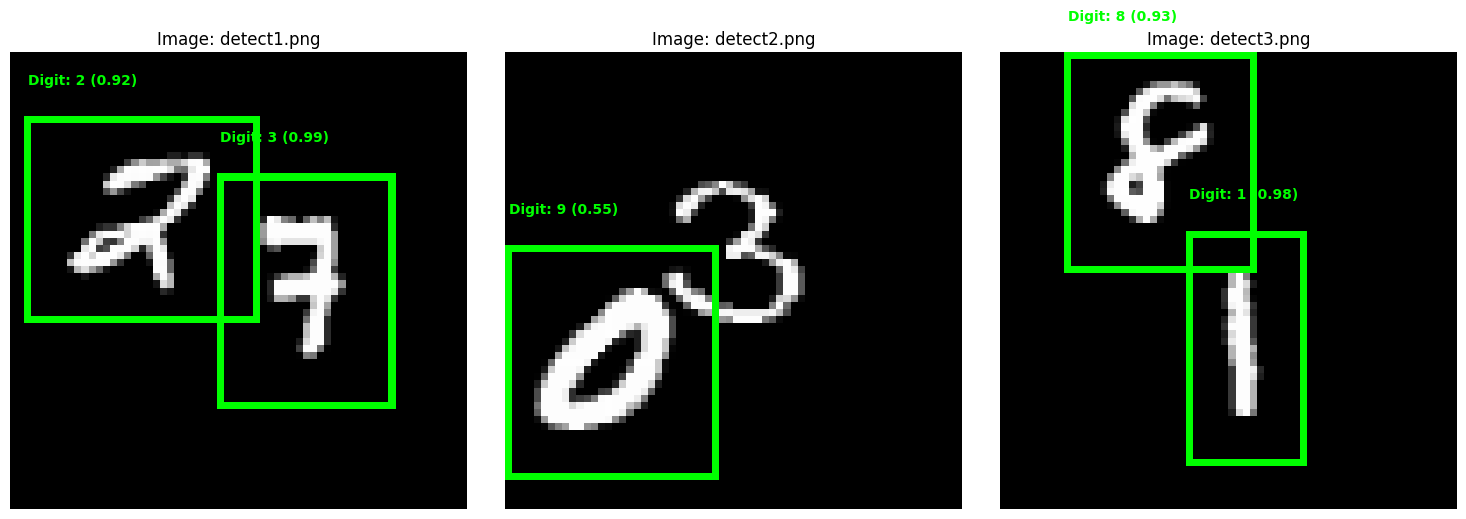

In [29]:
# Crop tightly, resize to 20px, center on 28x28 canvas — matches MNIST layout.
def preprocess_window(window):
    coords = cv2.findNonZero(window)
    if coords is None:
        return None

    x, y, w, h = cv2.boundingRect(coords)
    digit = window[y:y+h, x:x+w]

    scale = 20.0 / max(w, h)
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    digit = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((28, 28), dtype=np.uint8)
    x_off = (28 - new_w) // 2
    y_off = (28 - new_h) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = digit
    return canvas

# Core function to detect the digits with CNN
def detect_digits(image_path, model, min_area=50, pad=6):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, []

    # Threshold + morphological cleanup
    _, img_bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    img_bin = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kernel)
    img_bin = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN,  kernel)

    # Flip so digits=white, background=black for connected components
    img_bin = cv2.bitwise_not(img_bin)

    # Find connected components
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(img_bin)

    # Filter noise blobs, sort left-to-right
    blobs = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        if area >= min_area:
            blobs.append([x, y, x + w, y + h])

    blobs.sort(key=lambda b: b[0])

    # Classify each blob
    detections = []
    model.eval()
    with torch.no_grad():
        for (x1, y1, x2, y2) in blobs:
            x1p = max(0, x1 - pad)
            y1p = max(0, y1 - pad)
            x2p = min(img_bin.shape[1], x2 + pad)
            y2p = min(img_bin.shape[0], y2 + pad)
            crop = img_bin[y1p:y2p, x1p:x2p]

            window = preprocess_window(crop)
            if window is None:
                continue

            tensor = torch.from_numpy(window).float() / 255.0
            tensor = (tensor - 0.1307) / 0.3081
            tensor = tensor.unsqueeze(0).unsqueeze(0).to(device)

            output = model(tensor)
            probs = F.softmax(output, dim=1)
            conf, pred = torch.max(probs, 1)

            detections.append({
                'box':  (x1p, y1p, x2p - x1p, y2p - y1p),
                'conf': conf.item(),
                'pred': pred.item()
            })

    return img, detections


# Run detection on the three images
detect_files = ['detect1.png', 'detect2.png', 'detect3.png']
plt.figure(figsize=(15, 5))

for i, file in enumerate(detect_files):
    full_path = os.path.join(path, file)
    orig_img, results = detect_digits(full_path, model)

    plt.subplot(1, 3, i + 1)
    disp_img = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2RGB)

    for res in results:
        x, y, w, h = res['box']
        cv2.rectangle(disp_img, (x, y), (x + w, y + h), (0, 255, 0), 1)
        plt.text(x, y - 5, f"Digit: {res['pred']} ({res['conf']:.2f})",
                 color='lime', fontsize=10, fontweight='bold')

    plt.imshow(disp_img)
    plt.title(f"Image: {file}")
    plt.axis('off')

plt.tight_layout()
plt.show()

*In detect1, both digits were in bounding boxes. The first digit was classified with 92% but the digit 7 was misclassified with a 99% confidence, which is quite bad. In detect2, only one digit was identified and it had only 55% accuracy as a 9 when it was a 0. In detect3, both digits were classified correctly, which were an 8 and a 1.*

*I tried to do some preprocessing of the window to try and ceter digits, but that might have caused offset or scaling errors. For detect1, the 3 does have similar features to the 7, and if the curvature or stroke thickness was significantly different to the MNIST average, it could lead it to become overconfident as seen here. In detect2, the missing second box might be because of how I was filtering.*

###1.12 Discuss the limitations of your CNN in the context where your CNN will fail to recognize digits. Show any one example. [2 points]


***CNN Limitations*** <br>
*The CNN model trained on the standard MNIST dataset has the following limitations:*

*   *<u>Spatial Invariance:</u> The MNIST dataset consists of digits that are strictly centered within the standard size pixel box. If the digits in our dataset are not perfectly centered (though I tried), the model may fail to recognize features because they're not in the correct pixel location.*

*  *<u>Rotation:</u> CNN is not inherently invariant to changes in rotation. If the digit is tilted or of a different size, the filters might not work.*

*  *<u>Style Variation:</u> If the "style" of the digit in thickness, slant, stroke, or handwriting is far from the average look of the MNIST dataset, the features might be misinterpreted.

* <u>Over-Confidence:</u> I used softmax, which means that a high probability occurs for the top choice even when it's wrong.*

***Example*** <br>
*One example is where in detect1.png, the digit 7 was identified as a 3 with a 99% confidence. 7 shares high-level features of the 3 where there is a line to the right and 3 "arms" protruding to the left. This is an example of over-confidence and style variation.*

